In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import requests
import json

In [2]:
matches_df = pd.read_csv('best_2.csv')
results_df = pd.read_csv('series_result.csv')

In [3]:
matches_df = pd.merge(matches_df, results_df, how='left', on=['series_id','account_id'])

In [4]:
matches_df

,series_id,account_id,team,opp_team,leagueid,assists,camps_stacked,deaths,denies,firstblood_claimed,...,teamfight_score,obs_score,rune_score,fantasy_score,start_time,date,team_elo_(k=32)_rating,opp_team_elo_(k=32)_rating,elo_diff,result
0,633442,41637292,8606828,8261882,13742,20,0.0,5,25,0.0,...,1.578947,0.0,1.25,10.918947,1642379463,2022-01-17,800.00,942.77,-142.77,NaN
1,633442,92706637,8606828,8261882,13742,11,1.0,0,12,0.0,...,2.368421,1.0,4.00,23.500212,1642379463,2022-01-17,800.00,942.77,-142.77,NaN
2,633442,93159453,8261882,8606828,13742,17,0.0,9,0,0.0,...,1.800000,0.0,0.50,10.768396,1642379463,2022-01-17,942.77,800.00,142.77,NaN
3,633442,108624725,8261882,8606828,13742,18,3.0,8,0,0.0,...,2.200000,3.0,1.00,15.313018,1642379463,2022-01-17,942.77,800.00,142.77,NaN
4,633442,115750060,8261882,8606828,13742,15,0.0,10,0,0.0,...,1.600000,6.5,0.25,14.589634,1642379463,2022-01-17,942.77,800.00,142.77,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4710,682742,124801257,39,8261882,14281,30,1.0,5,16,0.0,...,4.410714,0.0,0.50,29.222587,1657049409,2022-07-05,1136.89,1005.77,131.12,0.0
4711,682742,131777279,8261882,39,14281,8,4.0,14,4,0.0,...,3.675000,7.0,1.75,21.048908,1657049409,2022-07-05,1005.77,1136.89,-131.12,2.0
4712,682742,154715080,39,8261882,14281,21,4.0,3,14,0.0,...,3.982143,2.5,3.50,28.145457,1657049409,2022-07-05,1136.89,1005.77,131.12,0.0
4713,682742,172739956,8261882,39,14281,7,0.0,5,25,0.0,...,4.425000,0.5,2.25,19.492165,1657049409,2022-07-05,1005.77,1136.89,-131.12,2.0


C:\Users\wicki\Anaconda3\envs\data-science\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='elo_diff', ylabel='fantasy_score'>

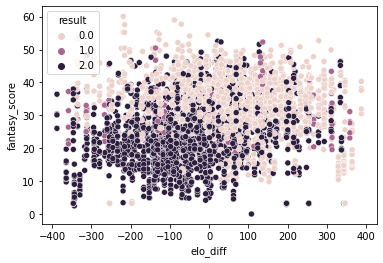

In [5]:
sns.scatterplot(matches_df['elo_diff'],matches_df['fantasy_score'],hue=matches_df['result'])

In [6]:
matches_df.groupby('result').mean()['fantasy_score']

result
0.0    32.535249
1.0    30.964981
2.0    23.842602
Name: fantasy_score, dtype: float64

In [7]:
data = pd.read_csv('proPlayers.csv')
data = data[['account_id','fantasy_role']]
matches_df = pd.merge(matches_df,data,how='left',on='account_id')

In [8]:
matches_df

,series_id,account_id,team,opp_team,leagueid,assists,camps_stacked,deaths,denies,firstblood_claimed,...,obs_score,rune_score,fantasy_score,start_time,date,team_elo_(k=32)_rating,opp_team_elo_(k=32)_rating,elo_diff,result,fantasy_role
0,633442,41637292,8606828,8261882,13742,20,0.0,5,25,0.0,...,0.0,1.25,10.918947,1642379463,2022-01-17,800.00,942.77,-142.77,NaN,1.0
1,633442,92706637,8606828,8261882,13742,11,1.0,0,12,0.0,...,1.0,4.00,23.500212,1642379463,2022-01-17,800.00,942.77,-142.77,NaN,4.0
2,633442,93159453,8261882,8606828,13742,17,0.0,9,0,0.0,...,0.0,0.50,10.768396,1642379463,2022-01-17,942.77,800.00,142.77,NaN,1.0
3,633442,108624725,8261882,8606828,13742,18,3.0,8,0,0.0,...,3.0,1.00,15.313018,1642379463,2022-01-17,942.77,800.00,142.77,NaN,2.0
4,633442,115750060,8261882,8606828,13742,15,0.0,10,0,0.0,...,6.5,0.25,14.589634,1642379463,2022-01-17,942.77,800.00,142.77,NaN,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4710,682742,124801257,39,8261882,14281,30,1.0,5,16,0.0,...,0.0,0.50,29.222587,1657049409,2022-07-05,1136.89,1005.77,131.12,0.0,1.0
4711,682742,131777279,8261882,39,14281,8,4.0,14,4,0.0,...,7.0,1.75,21.048908,1657049409,2022-07-05,1005.77,1136.89,-131.12,2.0,2.0
4712,682742,154715080,39,8261882,14281,21,4.0,3,14,0.0,...,2.5,3.50,28.145457,1657049409,2022-07-05,1136.89,1005.77,131.12,0.0,4.0
4713,682742,172739956,8261882,39,14281,7,0.0,5,25,0.0,...,0.5,2.25,19.492165,1657049409,2022-07-05,1005.77,1136.89,-131.12,2.0,4.0


In [9]:
cores = matches_df[matches_df['fantasy_role']==1.0]
supports = matches_df[matches_df['fantasy_role']==2.0]
mids = matches_df[matches_df['fantasy_role']==4.0]

C:\Users\wicki\Anaconda3\envs\data-science\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='elo_diff', ylabel='fantasy_score'>

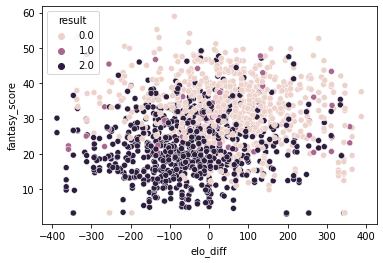

In [10]:
sns.scatterplot(cores['elo_diff'],cores['fantasy_score'],hue=cores['result'])

C:\Users\wicki\Anaconda3\envs\data-science\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='elo_diff', ylabel='fantasy_score'>

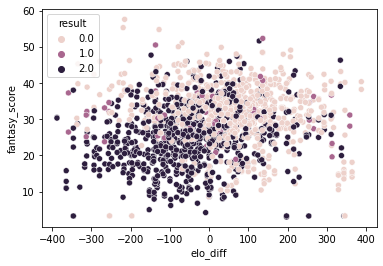

In [11]:
sns.scatterplot(supports['elo_diff'],supports['fantasy_score'],hue=supports['result'])

C:\Users\wicki\Anaconda3\envs\data-science\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='elo_diff', ylabel='fantasy_score'>

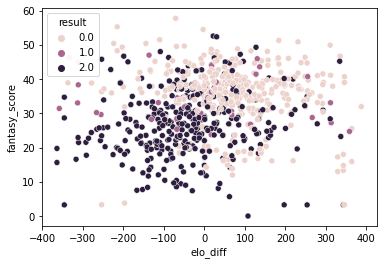

In [12]:
sns.scatterplot(mids['elo_diff'],mids['fantasy_score'],hue=mids['result'])

<AxesSubplot:>

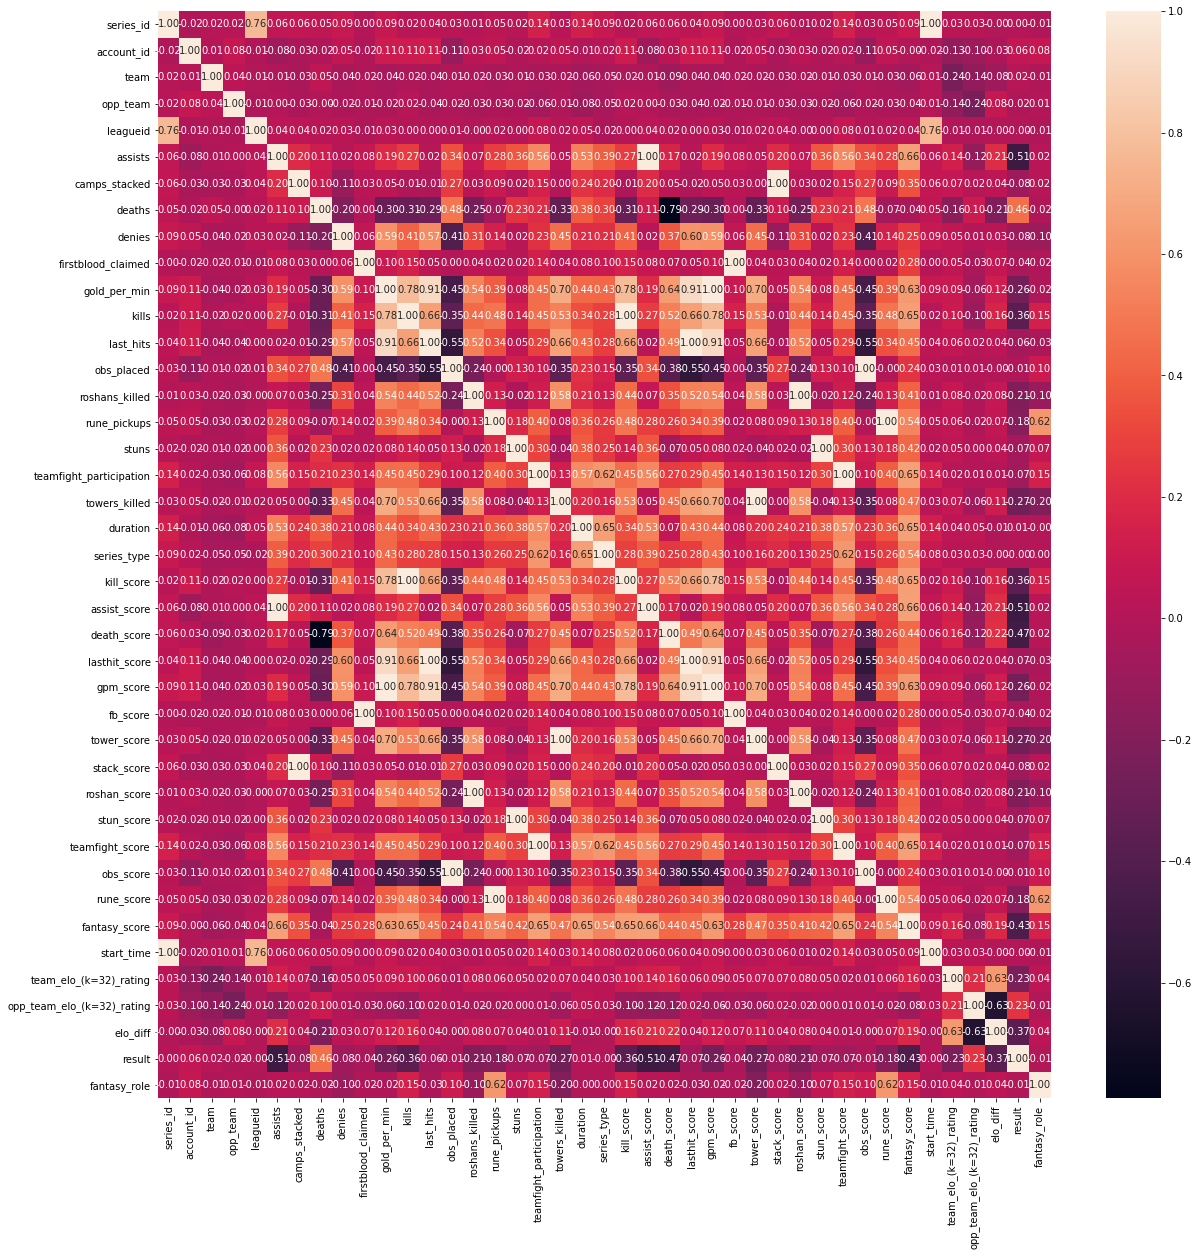

In [13]:
plt.figure(figsize=(20,20))
sns.heatmap(matches_df.corr(),annot=True,fmt='.2f')

In [14]:
matches_df.sort_values(['account_id','series_id'],ascending=False,inplace=True)

In [15]:
data = matches_df.groupby('account_id').count()['series_id'].values

<AxesSubplot:ylabel='Count'>

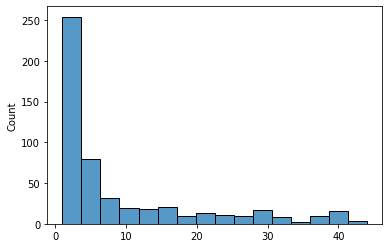

In [16]:
sns.histplot(data)

In [17]:
matches_df.to_csv('finalized_df.csv',index=False)

In [18]:
all_df = pd.read_csv('player_data.csv')

C:\Users\wicki\Anaconda3\envs\data-science\lib\site-packages\IPython\core\interactiveshell.py:3165: DtypeWarning: Columns (17) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


In [26]:
most_10 = all_df.groupby('account_id').count().sort_values('assists').tail(10).index

In [27]:
for player in most_10:
    all_df[all_df['account_id']==player]

86822085
148215639
91369376
157475523
207829314
129958758
107803494
111030315
118134220
111114687


In [38]:
all_df

,match_id,account_id,assists,camps_stacked,deaths,denies,firstblood_claimed,gold_per_min,kills,last_hits,...,roshans_killed,rune_pickups,stuns,teamfight_participation,towers_killed,start_time,radiant_win,isRadiant,win,lose
0,6676261920,87278757,4,5.0,9,4,1.0,264,2,82,...,0.0,6.0,6.098511,0.555556,0.0,1658681522,False,True,0,1
1,6676261920,111030315,4,0.0,11,1,0.0,209,3,32,...,0.0,1.0,20.296337,0.777778,1.0,1658681522,False,True,0,1
2,6676261920,127617979,3,2.0,8,10,0.0,394,1,198,...,0.0,1.0,0.000000,0.444444,0.0,1658681522,False,True,0,1
3,6676261920,86725175,3,2.0,8,8,0.0,464,1,192,...,0.0,1.0,12.993971,0.444444,1.0,1658681522,False,True,0,1
4,6676261920,121769650,3,2.0,9,7,0.0,439,2,252,...,0.0,5.0,5.498510,0.555556,1.0,1658681522,False,True,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103475,644342976,38271450,10,NaN,0,0,NaN,408,8,19,...,NaN,NaN,NaN,NaN,NaN,1399295805,False,False,1,0
103476,644342976,86827378,6,NaN,0,3,NaN,331,1,28,...,NaN,NaN,NaN,NaN,NaN,1399295805,False,False,1,0
103477,644342976,66598119,11,NaN,2,1,NaN,410,4,54,...,NaN,NaN,NaN,NaN,NaN,1399295805,False,False,1,0
103478,644342976,86874930,10,NaN,0,22,NaN,610,10,92,...,NaN,NaN,NaN,NaN,NaN,1399295805,False,False,1,0


In [69]:
request = requests.request('GET','https://api.opendota.com/api/matches/6676261920?api_key=c4b80265-46ad-4728-b0f4-ae0c1a175bef')
data = request.json()

In [72]:
player1 = data['players'][1]

In [77]:
player1['gold_reasons']

{'0': 600,
 '1': -977,
 '6': 90,
 '11': 420,
 '12': 1032,
 '13': 899,
 '14': 102,
 '16': 105,
 '17': 601,
 '20': 164}

In [68]:
request = requests.request('GET','https://api.opendota.com/api/heroes/')
heroes = request.json()

In [71]:
len(data['teamfights'])

5

In [78]:
request = requests.request('GET','https://api.opendota.com/api/constants/')
constants = request.json()

In [79]:
constants

['abilities',
 'ability_ids',
 'aghs_desc',
 'ancients',
 'chat_wheel',
 'cluster',
 'countries',
 'game_mode',
 'hero_abilities',
 'hero_lore',
 'hero_names',
 'heroes',
 'item_colors',
 'item_ids',
 'items',
 'lobby_type',
 'neutral_abilities',
 'order_types',
 'patch',
 'patchnotes',
 'permanent_buffs',
 'player_colors',
 'region',
 'skillshots',
 'xp_level']